# **1. Model Selection & Rationale**

In this section, three supervised learning models are selected to predict loan approval outcomes. For each model, the discussion covers the problem type and dataset characteristics. Additionally, the strengths and weaknesses of each model are analyzed to evaluate their suitability for this problem.


### *1. Logistic Regression*

Logistic Regression was chosen as a supervised learning algorithm for the prediction of the loan approval problem for a number of reasons related to the characteristics of the given data and the type of the problem to be solved.

**Dataset Characteristics**

The dataset contains approximately **4269 observations** and a set of **numerical and categorical features** describing the financial attributes of loan applicants. These features include variables such as income, loan amount, credit score, asset values, and several derived financial ratios. Because most of the input variables are numerical and represent structured financial information, Logistic Regression is suitable as it performs well with structured tabular data and numerical predictors.

In addition, several features in the dataset represent **financial ratios** such as *loan_to_income_ratio* and *asset_to_loan_ratio*. These types of features often have relationships with the target variable that can be approximated with linear decision boundaries, making Logistic Regression a reasonable model to test for this problem.

**Problem Type**

The target variable is **loan_status**, indicating whether the loan is approved or rejected. This is a **binary classification problem** since the target variable has only two possible values. The Logistic Regression algorithm is particularly suited to binary classification problems. In binary classification problems, the Logistic Regression algorithm calculates the probability of an instance belonging to the positive class. In the context of the problem, the positive class is the class of loan applications that are approved. Therefore, it is able to output both a class label and a probability, which is helpful when computing ROC-AUC scores.


**Model Strengths and Weaknesses for this Problem**

One of the main strengths of Logistic Regression is its **simplicity and interpretability**. The model provides a clear relationship between the input features and the predicted outcome, making it easier to understand how different financial attributes influence loan approval decisions. Additionally, Logistic Regression is computationally efficient and works well as a **baseline model** that establishes a reference level of performance before applying more complex algorithms.

However, Logistic Regression assumes a **linear relationship between the features and the decision boundary**. In real-world financial datasets, loan approval decisions may depend on more complex interactions between variables such as income, credit score, asset values, and loan ratios. As a result, Logistic Regression may not fully capture nonlinear relationships in the data.

### *2. Support Vector Machine (SVM)*

**Dataset** **Characteristics**

The dataset contains approximately **4,269** observations and a set of **numerical and categorical features** describing the financial attributes of loan applicants. These features include both original financial attributes and engineered variables such as loan_to_income_ratio and total_assets. Because the dataset contains multiple numerical financial variables describing the applicant’s financial status, it creates a moderately high-dimensional feature space. Support Vector Machine performs well in such settings because it is effective in high-dimensional spaces and can construct decision boundaries that separate classes even when many features are involved.

Additionally, the dataset includes variables such as CIBIL category, income, and asset values that may interact in complex ways when determining loan approval outcomes. These interactions may not always follow a simple linear pattern. Therefore, SVM is a suitable model to explore for this dataset because it can handle both linear and non-linear relationships through the use of kernel functions.

**Problem Type**

The target variable in this dataset is loan_status, which indicates whether a loan application is approved or rejected. This represents a binary classification problem because the target variable contains two possible classes.

Support Vector Machine is well-suited for binary classification tasks. The algorithm works by identifying the optimal decision boundary (hyperplane) that separates the two classes while maximizing the margin between them. In this project, the Radial Basis Function (RBF) kernel is used to allow the model to capture potential non-linear relationships between financial features and the loan approval outcome. For example, the relationship between CIBIL category and approval status may not be strictly linear, since approval likelihood can change sharply once a credit score passes certain thresholds.

Additionally, the dataset shows a mild class imbalance (2,656 approved vs. 1,613 rejected applications). To address this issue, the parameter class_weight = "balanced" is used to ensure that the model does not become biased toward the majority class during training.

**Model Strengths and Weaknesses for This Problem**

One of the strengths of Support Vector Machine is its ability to perform well in datasets with multiple numerical features and potentially complex relationships between variables. By using kernel functions such as the RBF kernel, SVM can capture non-linear patterns between financial attributes and loan approval outcomes. This allows the model to identify decision boundaries that separate approved and rejected loan applications more effectively than simple linear models in some cases.

However, SVM also has several limitations in the context of this problem. One limitation is limited interpretability. Unlike models such as Logistic Regression or Random Forest, SVM does not easily provide clear explanations about which financial variables most strongly influence the prediction. This can be a concern in financial applications where understanding the reasoning behind approval decisions is important.

Another limitation is sensitivity to feature scaling. The dataset contains financial variables with significantly different ranges, such as income values that may reach millions and loan terms measured in years. Without proper scaling, features with larger numeric ranges could dominate the model. Therefore, preprocessing techniques such as StandardScaler must be applied before training the SVM model to ensure that all features contribute equally to the decision boundary.

### *3. Random Forest*

Random Forest was selected as a supervised learning algorithm for the prediction of the loan approval problem due to its ability to capture complex patterns in structured financial data and improve prediction performance through ensemble learning.

**Dataset Characteristics**

The dataset contains approximately **4269 observations** and a combination of **numerical and categorical features** representing the financial attributes of loan applicants. These features include variables such as income, loan amount, CIBIL score, employment status, asset values, and several derived financial ratios. Since the dataset is structured and contains multiple interacting variables, Random Forest is well-suited for modeling such data.

In addition, the relationships between these financial features and the target variable are often **nonlinear**. For example, the effect of credit score or income on loan approval may change depending on other factors such as loan amount or asset value. Random Forest can effectively handle these interactions by constructing multiple decision trees that learn different patterns in the data.

**Problem Type**

The target variable is **loan_status**, which indicates whether a loan application is approved or rejected. This represents a **binary classification problem** since the target variable has two possible outcomes.

Random Forest is well-suited for binary classification tasks because it combines the predictions of multiple decision trees using a majority voting mechanism. This approach improves the model’s stability and reduces the likelihood of overfitting compared to a single decision tree. Additionally, Random Forest can handle slight class imbalance in the dataset and still produce reliable predictions.

**Model Strengths and Weaknesses for this Problem**

One of the main strengths of Random Forest is its ability to model **nonlinear relationships and complex feature interactions** without requiring strong assumptions about the data. This makes it particularly effective for financial datasets where multiple variables influence loan approval decisions. Furthermore, Random Forest reduces overfitting by averaging multiple trees, leading to better generalization on unseen data.

Another important advantage is that Random Forest provides **feature importance scores**, which help identify the most influential variables affecting loan approval, such as credit score, income, and asset values.

However, Random Forest has some limitations. It is generally **less interpretable** than simpler models like Logistic Regression, making it harder to explain individual predictions. Additionally, it can be **computationally more expensive**, especially when using a large number of trees.

# **2. Implementation & Training**


In this section, three supervised learning models are implemented and
trained on the preprocessed loan approval dataset: Logistic Regression,
Support Vector Machine (SVM), and Random Forest. Each model is trained
and evaluated independently to allow for a fair comparison of their
performance.

The implementation process follows the same general steps for all models:

1. Load the preprocessed dataset saved from the data exploration phase.
2. Separate the feature variables (X) from the target variable (y).
3. Split the dataset into training and testing sets using an 80/20 ratio,
   where 80% of the data is used for training and 20% is reserved for
   testing. This ratio was chosen because the dataset contains 4,269
   records, which is a moderate size. Allocating 80% for training ensures
   that the models have sufficient data to learn meaningful patterns, while
   reserving 20% provides a large enough test set to produce reliable
   evaluation results. Stratified splitting is applied to preserve the
   original class distribution in both sets, which is important given the
   mild class imbalance between approved and rejected applications.
4. Apply feature scaling using StandardScaler where required. This step
   is essential for Logistic Regression and SVM, as both models are
   sensitive to differences in feature ranges. Random Forest does not
   require scaling since it is a tree-based model that splits data based
   on feature values rather than distances.
5. Train each model classifier on the training data.


### i. Logistic Regression

The Logistic Regression model was implemented using the Scikit-learn
library in Python. Before training the model, the dataset was divided
into training and testing sets in order to evaluate the model's
performance on unseen data. An 80/20 split was used, where 80% of
the data was used for training and 20% for testing.

Since Logistic Regression is sensitive to the scale of input features,
feature scaling was applied using StandardScaler to normalize the
feature values. The scaler was fitted only on the training data and
then applied to both the training and testing sets to prevent data
leakage. This ensures that variables with larger numeric ranges, such
as income or asset values, do not dominate the model during training.

The Logistic Regression classifier was configured with
class_weight="balanced" to address the mild class imbalance present
in the dataset, and max_iter=1000 to ensure the optimization algorithm
converges successfully.

In [22]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("preprocessed_loan_data_v2.csv")

# Separate features and target
X = data.drop("loan_status", axis=1)
y = data["loan_status"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Scale first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Define model
logistic_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Initialize Logistic Regression model
#logistic_model = LogisticRegression(max_iter=1000)

# Train model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model training completed.")

Logistic Regression model training completed.


### ii. SVM

the Support Vector Machine (SVM) model was implemented using the Scikit-learn library in Python. Before training the model, the dataset was divided into training and testing sets in order to evaluate the model’s performance on unseen data. An 80/20 split was used, where 80% of the data was used for training and 20% for testing.

Since SVM is sensitive to the scale of input features, feature scaling was applied using StandardScaler to normalize the feature values. This ensures that variables with larger numeric ranges, such as income or asset values, do not dominate the model during training.

The SVM classifier was implemented using the Radial Basis Function (RBF) kernel, which allows the model to capture potential non-linear relationships between financial features and loan approval outcomes. Additionally, the parameter class_weight="balanced" was used to address the mild class imbalance present in the dataset.

In [23]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Load dataset
data = pd.read_csv("preprocessed_loan_data_v2.csv")

# Define features and target
X = data.drop("loan_status" , axis=1)
y = data["loan_status"]

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create an SVM pipeline that applies feature scaling (StandardScaler)
# before training the SVM model to ensure all features contribute equally
# and to avoid issues caused by different feature ranges.

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))
])

# Train the model
svm_model.fit(X_train, y_train)

print("SVM model training completed.")


SVM model training completed.


### iii. Random Forest

The Random Forest model was implemented using the Scikit-learn library in Python. Prior to training, the dataset was split into training and testing sets to evaluate how well the model generalizes to unseen data. An 80/20 split was applied, where 80% of the data was used for training and 20% for testing.

In contrast to models such as Logistic Regression and SVM, Random Forest does not rely on distance-based calculations. Therefore, feature scaling was not required. This simplifies the preprocessing step and allows the model to work directly with the original feature values.

The Random Forest classifier was initialized with a fixed random_state to ensure consistent and reproducible results. By combining multiple decision trees, the model is able to capture complex relationships between input features such as income, credit score, and asset values, and the final loan approval decision. This ensemble approach also helps in reducing overfitting compared to a single decision tree.

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data = pd.read_csv("preprocessed_loan_data_v2.csv")
# Load dataset
data = pd.read_csv("preprocessed_loan_data_v2.csv")

# Define features and target
X = data.drop("loan_status", axis=1)
y = data["loan_status"]

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model training completed.")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated for test dataset.")

Random Forest model training completed.
Predictions generated for test dataset.


* The Random Forest model was configured with n_estimators=100, meaning that 100 decision trees are used in the ensemble.
This value was selected as it provides a good balance between model performance and computational efficiency.
Increasing the number of trees generally improves prediction stability and reduces variance, but it also increases training time.

* A fixed random_state=42 was used to ensure reproducibility of the results.
This guarantees that the data splitting and model behavior remain consistent across different runs, which is essential for reliable evaluation and comparison.


# **3. Hyperparameter Tuning Process & Results**



Hyperparameter tuning was applied to all three models to identify the
optimal configuration for each. GridSearchCV was used to systematically
evaluate all possible combinations of hyperparameter values, ensuring
that the best configuration is identified without manual trial and error.
The tuning process was performed using 5-fold cross-validation for all
models. This approach was chosen because the dataset size is moderate
(4,269 records). Using 5 folds provides a reliable estimate of model
performance while keeping the computational cost manageable. A higher
number of folds such as 10 would increase computation time significantly
without offering a meaningful improvement in evaluation reliability for
a dataset of this size. The F1-score was used as the scoring metric
across all models to account for the mild class imbalance in the dataset.

### i. Logistic Regression

 **Hyperparameter Tuning Process - Logistic Regression**

Logistic Regression performance can be influenced by several hyperparameters,
particularly C and the solver. These parameters control how strongly the model
is regularized and how the optimization algorithm fits the model to the training
data.

To identify the optimal configuration, GridSearchCV was used to systematically
evaluate multiple combinations of hyperparameter values. The tuning process was
performed using 5-fold cross-validation, which means the training data was
divided into five subsets. The model was trained and validated five times, each
time using a different fold for validation and the remaining folds for training.

The following hyperparameters were explored:

**C**: Controls the regularization strength. Smaller values apply stronger
regularization and produce simpler decision boundaries, while larger values
allow the model to fit the training data more closely at the risk of overfitting.

**solver**: Defines the optimization algorithm used to fit the model. In this
experiment, both lbfgs and liblinear solvers were tested. The lbfgs solver is
suitable for datasets with multiple numerical features, while liblinear is
more efficient for smaller datasets with simple linear boundaries.

The hyperparameter combinations were evaluated using the F1-score as the
scoring metric. The F1-score was chosen because it balances precision and
recall, making it suitable for classification problems where both false
positives and false negatives are important.

In [25]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Tuning
param_grid_lr = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_search_lr = GridSearchCV(
    logistic_model,
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_scaled, y_train)
best_lr_model = grid_search_lr.best_estimator_

print("Best parameters:", grid_search_lr.best_params_)
print("Best CV F1-score:", round(grid_search_lr.best_score_, 4))
print("Logistic Regression training completed.")

# Logistic Regression
train_score = best_lr_model.score(X_train_scaled, y_train)
test_score  = best_lr_model.score(X_test_scaled, y_test)



Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best CV F1-score: 0.8829
Logistic Regression training completed.


**Hyperparameter Tuning Results**

After evaluating all combinations, the best performing configuration was identified as:

GridSearchCV evaluated 10 different combinations of hyperparameters
across 5 folds, resulting in a total of 50 fitting iterations.

The best performing configuration was identified as:

- **C = 0.01**
- **solver = lbfgs**

This configuration achieved a cross-validation F1-score of **0.9328**.

The optimal value of C = 0.01 indicates that strong regularization
was beneficial for this dataset. This means the model performs better
when it is penalized for overly complex decision boundaries, which
suggests that a simpler linear relationship between the financial
features and loan approval outcome is sufficient for Logistic Regression
to generalize well.

The lbfgs solver was selected as the best optimization algorithm.
This solver is well-suited for datasets with multiple numerical features
and handles the scaled input effectively.

### ii. SVM

**Hyperparameter Tuning Process**

Support Vector Machine performance can be significantly influenced by several hyperparameters, particularly C, gamma, and the kernel function. These parameters control how the model fits the training data and how complex the decision boundary becomes.

To identify the optimal configuration, GridSearchCV was used to systematically evaluate multiple combinations of hyperparameter values. The tuning process was performed using 5-fold cross-validation, which means the training data was divided into five subsets. The model was trained and validated five times, each time using a different fold for validation and the remaining folds for training.

The following hyperparameters were explored:

C: Controls the regularization strength. Smaller values allow more misclassification but improve generalization, while larger values attempt to classify all training examples correctly.

gamma: Determines how far the influence of a single training example reaches in the RBF kernel. Smaller values create smoother decision boundaries, while larger values allow more complex boundaries.

kernel: Defines the transformation used to separate the classes. In this experiment, both linear and RBF kernels were tested.

The hyperparameter combinations were evaluated using the F1-score as the scoring metric. The F1-score was chosen because it balances precision and recall, making it suitable for classification problems where both false positives and false negatives are important

In [26]:
from sklearn.model_selection import GridSearchCV
# Define hyperparameter grid
param_grid = {
    "svm__C": [0.01,0.1, 1, 10], # Regularization strength
    "svm__gamma": ['scale', 0.1, 0.01],  # Kernel coefficient
    "svm__kernel": ['rbf' , 'linear'] # Kernel type
}


# ── Grid Search
# scoring='f1' chosen because the dataset has mild class imbalance;
# F1 balances precision and recall, making it a fair evaluation metric
grid_search = GridSearchCV(
    svm_model,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1

)

grid_search.fit(X_train, y_train)

best_svm_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Best CV score: 0.9087207197775365


**Hyperparameter Tuning Results**

After evaluating all combinations, the best performing configuration was identified as:

C = 10

gamma = 'scale'

kernel = 'rbf'

This configuration achieved a cross-validation F1-score of approximately 0.955, indicating that the tuned SVM model performs very well in balancing precision and recall when classifying loan approval outcomes.

The use of the RBF kernel suggests that the relationship between the input features and the loan approval outcome is non-linear, meaning the model benefits from a flexible decision boundary rather than a simple linear separation.

The relatively high value of C indicates that the model prefers a decision boundary that minimizes classification errors on the training data while still maintaining generalization through cross-validation.

The tuned model obtained from the grid search was then selected as the final SVM model and used in the subsequent evaluation stage.

### iii. Random Forest

\
**Hyperparameter Tuning Process – Random Forest**

Random Forest performance can be influenced by several hyperparameters, particularly the number of trees, the maximum depth of each tree, and the minimum number of samples required for splitting. These parameters control how complex each tree becomes and how well the model generalizes to unseen data.

To identify the optimal configuration, GridSearchCV was used to evaluate multiple combinations of hyperparameter values. The tuning process was performed using 5-fold cross-validation, where the training data was divided into five subsets. The model was trained and validated multiple times, each time using a different fold for validation.

The following hyperparameters were explored:

n_estimators: Controls the number of decision trees in the forest. A higher number of trees generally improves performance but increases computational cost.

max_depth: Limits the depth of each tree. Smaller values help reduce overfitting, while larger values allow the model to capture more complex patterns.

min_samples_split: Determines the minimum number of samples required to split a node. Higher values prevent the model from creating overly complex trees.

The hyperparameter combinations were evaluated using the F1-score as the scoring metric. The F1-score was selected because it balances precision and recall, making it suitable for classification problems with mild class imbalance.

In [27]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Grid Search
grid_search_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_

print("Best parameters:", grid_search_rf.best_params_)
print("Best CV score:", grid_search_rf.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 150}
Best CV score: 0.9378128391317606


**Hyperparameter Tuning Results – Random Forest**

After evaluating all combinations, the best performing configuration was identified as:

n_estimators = 150
max_depth = 5
min_samples_split = 5

This configuration achieved a cross-validation F1-score of 0.9378.
The selected hyperparameters indicate that controlling model complexity was essential for achieving strong performance. The relatively shallow depth (max_depth = 5) helps reduce the risk of overfitting by limiting tree complexity, while the use of multiple trees (n_estimators = 150) improves model stability and robustness. Additionally, setting min_samples_split = 5 encourages the model to avoid splitting nodes based on too few samples, which reduces the likelihood of creating overly specific decision boundaries that do not generalize well to unseen data.
While the cross-validation F1-score reflects strong performance, further evaluation on unseen test data is necessary to confirm the model's ability to generalize.

# **4. Comperhensive Evaluation**


This section evaluates the trained supervised learning model using multiple performance metrics and visualizations. Since the target variable (`loan_status`) is binary, the evaluation includes both standard classification metrics and binary-specific measures such as ROC-AUC and the ROC curve.


The purpose of using multiple evaluation metrics is to avoid relying on a single measure of performance. For example, accuracy alone may not fully reflect model quality when the classes are imbalanced. Precision, recall, and F1-score provide additional insight into the model’s classification behavior, especially in distinguishing approved and rejected loan applications.


The following metrics are used:

- **Accuracy**: Measures the overall proportion of correct predictions.
- **Precision**: Measures the proportion of predicted positive cases that are actually positive.
- **Recall**: Measures the proportion of actual positive cases that are correctly identified.
- **F1-Score**: Combines precision and recall into a single score.
- **Confusion Matrix**: Shows the distribution of true positives, true negatives, false positives, and false negatives.
- **ROC-AUC**: Measures how well the model distinguishes between the two classes across different thresholds.


In addition, **5-fold cross-validation** is used to evaluate the model’s stability across multiple splits of the dataset.


The visualizations included in this section are:
- **Confusion matrix heatmap**
- **ROC curve**
- **Feature importance plot** for tree-based models only

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import cross_val_score

### Function 1: `get_predictions_and_scores`



This is a helper function that prepares the outputs needed by the rest of the evaluation pipeline.

Its role is to generate the predicted class labels for the test set (`y_pred`) and the predicted probability scores for the positive class, when the model supports probability estimation (`y_score`).

The reason this function is useful is that not all models provide the same kind of output. Every classifier can usually return class predictions using `predict()`, but only some classifiers provide probability estimates through `predict_proba()`.

For example:
- Logistic Regression supports `predict_proba()`
- Random Forest supports `predict_proba()`
- SVM only supports probability outputs if it is initialized with `probability=True`

The ROC curve and ROC-AUC metric require probability-like scores rather than final class labels. Therefore, this helper function makes the later evaluation functions more flexible by handling that step in one place.

In [29]:
def get_predictions_and_scores(model, X_test):
    """
    Returns:
    - y_pred: predicted class labels
    - y_score: predicted probability scores for class 1 if available, otherwise None
    """
     # Generate the final predicted class labels, such as 0 or 1
    y_pred = model.predict(X_test)

    # Check whether the model supports class probability estimation
    if hasattr(model, "predict_proba"):
        # For binary classification, [:, 1] extracts the probability
        # of belonging to the positive class (class 1)
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        # If probability scores are unavailable, return None
        y_score = None

    return y_pred, y_score

### Function 2: `evaluate_metrics`



This function computes the main numerical evaluation metrics for a classification model.

It uses the predicted class labels produced by the helper function and calculates Accuracy, Precision, Recall, F1-score and OC-AUC.

This function returns the results in a dictionary so that they can later be printed clearly in the notebook, stored in variables and added to a comparison table for all models

In [30]:
def evaluate_metrics(model, X_test, y_test, model_name):
    """
    Computes and prints the main classification metrics.
    Returns a dictionary containing Accuracy, Precision, Recall, F1 Score, and ROC-AUC (if available).
    """

    os.makedirs("Supervised_Learning/evaluation_results", exist_ok=True)

    # Get predicted labels and probability scores using the helper function
    y_pred, y_score = get_predictions_and_scores(model, X_test)

    # Compute standard classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store the results in a dictionary for later reuse
    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    # Print the metric results in a clear format
    print(f"===== {model_name} Metrics =====")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    # ROC-AUC requires probability scores, so calculate it only if available
    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
        results["ROC-AUC"] = roc_auc
        print("ROC-AUC:", roc_auc)
    else:
        results["ROC-AUC"] = None
        print("ROC-AUC: Not available for this model")

    df = pd.DataFrame([results])
    file_name = model_name.replace(" ", "_") + "_metrics.csv"
    df.to_csv(f"Supervised_Learning/evaluation_results/{file_name}", index=False)


    return results

### Function 3: `plot_confusion_matrix`



This function creates a confusion matrix heatmap for the selected model.

A confusion matrix compares:
- the **actual class labels**
- the **predicted class labels**

In binary classification, the matrix contains four outcomes:
- **True Positives**
- **True Negatives**
- **False Positives**
- **False Negatives**

This visualization is useful because it does not only tell us how many predictions were correct overall, but also shows the pattern of mistakes made by the model.

For example, in a loan approval problem:
- a false positive means the model predicted approval when the application should have been rejected
- a false negative means the model predicted rejection when the application should have been approved


In [31]:
def plot_confusion_matrix(model, X_test, y_test, model_name):
    """
    Generates and displays the confusion matrix heatmap.
    """

    os.makedirs("Supervised_Learning/plots", exist_ok=True)

    # Generate predicted class labels
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Create the heatmap visualization
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    # Label the plot
    plt.title(f"Confusion Matrix Heatmap - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.savefig(f"Supervised_Learning/plots/{model_name}_cm.png")
    # Display the plot
    plt.show()

### Function 4: `plot_roc`



This function draws the Receiver Operating Characteristic (ROC) curve for a binary classification model.

The ROC curve shows the relationship between:
- **True Positive Rate**
- **False Positive Rate**

across different classification thresholds.

This is important because some models do not just produce a final class label; they produce a probability score. By changing the threshold used to convert that score into a class prediction, the model’s sensitivity and specificity also change.

The function also computes the **ROC-AUC score**, which summarizes the entire ROC curve into a single value:
- a value close to **1.0** means excellent class separation
- a value close to **0.5** means the model performs similarly to random guessing

If the model does not provide probability scores, the function prints a message and skips the plot.

In [32]:
def plot_roc(model, X_test, y_test, model_name):
    """
    Generates and displays the ROC curve if probability scores are available.
    Returns the ROC-AUC value if probability scores are available. Otherwise, returns None.
    """
     # Get the prediction scores needed for ROC analysis
    _, y_score = get_predictions_and_scores(model, X_test)

    # ROC analysis requires probability scores
    if y_score is None:
        print(f"ROC curve is not available for {model_name} because probability scores are not supported.")
        return None

    # Compute the false positive rate, true positive rate, and thresholds
    fpr, tpr, _ = roc_curve(y_test, y_score)

    # Compute the AUC value
    roc_auc = roc_auc_score(y_test, y_score)

    # Plot the ROC curve
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")

    # Plot the diagonal reference line for random guessing
    plt.plot([0, 1], [0, 1], linestyle="--")

    # Add plot labels and title
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.savefig(f"Supervised_Learning/plots/{model_name}_roc.png")
    plt.show()

    return roc_auc

### Function 5: `evaluate_cross_validation`



This function performs k-fold cross-validation for the selected model.

Cross-validation is used to estimate how well a model generalizes to unseen data. Instead of relying on one fixed train-test split, the dataset is divided into multiple folds. The model is trained and validated several times, each time using a different fold for validation and the remaining folds for training.

In this project, accuracy is used as the scoring metric during cross-validation.

The function prints:
- the accuracy score for each fold
- the mean cross-validation accuracy
- the standard deviation

The mean score provides an overall estimate of model performance, while the standard deviation shows how stable the model is across different splits.

In [33]:
def evaluate_cross_validation(model, X, y, model_name, cv=5):
    """
    Performs k-fold cross-validation and prints the results.
    Returns the cross-validation accuracy scores for each fold.
    """
     # Perform k-fold cross-validation using accuracy as the scoring metric
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

    # Print the cross-validation results
    print(f"===== {model_name} Cross-Validation ({cv}-Fold) =====")
    print("Cross-validation scores:", cv_scores)
    print("Mean CV accuracy:", cv_scores.mean())
    print("Standard deviation:", cv_scores.std())

    df = pd.DataFrame({
        "Fold": list(range(1, cv+1)),
        "Accuracy": cv_scores
    })

    df.loc["Mean"] = ["Mean", cv_scores.mean()]
    df.loc["Std"]  = ["Std", cv_scores.std()]

    file_name = model_name.replace(" ", "_") + "_cv_results.csv"
    df.to_csv(f"Supervised_Learning/evaluation_results/{file_name}", index=False)


    return cv_scores

## Evaluation of Logistic Regression

###1. Evaluation Metrics

In [34]:
logistic_metrics = evaluate_metrics(
    best_lr_model, #
    X_test_scaled, #
    y_test,
    "Logistic Regression"
)

===== Logistic Regression Metrics =====
Accuracy: 0.8676814988290398
Precision: 0.8913857677902621
Recall: 0.896421845574388
F1 Score: 0.8938967136150234
ROC-AUC: 0.9480680764723373


### Interpretation of Logistic Regression Evaluation Metrics

The Logistic Regression model has been able to achieve a high **accuracy of 86.77%**, which means that it is able to correctly classify more than eight out of every ten loan applications in the test dataset.

The precision score of **approximately 0.891** indicates that when the model predicts a loan application as approved, about 89.1% of those predictions are correct.

The recall score of **approximately 0.896** indicates that the model is able to correctly identify around 89.6% of all loan applications that should be approved. This suggests that the model is effective at detecting positive cases (approved loans), although it may sometimes miss some applications that should be approved.

The F1 score of **around 0.894** suggests a balance between precision and recall. This high F1 score implies that the model has a good balance between identifying approved loans and avoiding incorrect approvals.

Lastly, the ROC-AUC score of **around 0.948** suggests that the model has a high ability to distinguish between approved and rejected loans across different classification thresholds. A value close to 1 indicates excellent separability between classes, confirming that the model performs significantly better than random guessing.

Overall, the Logistic Regression model performs well for the loan approval prediction task. It maintains a balanced trade-off between correctly identifying approved loans and avoiding incorrect approvals, making it a reliable and interpretable baseline model.

### 2. Confusion Matrix

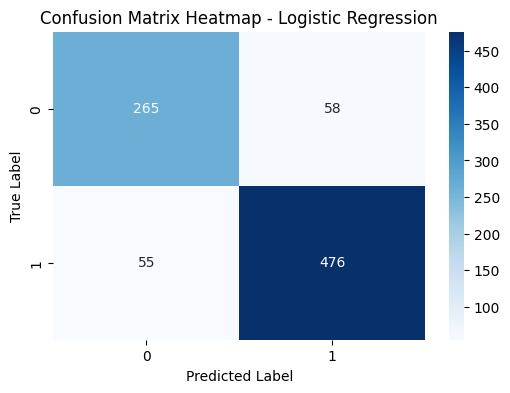

In [35]:
logistic_cm = plot_confusion_matrix(
    best_lr_model, #
    X_test_scaled, #
    y_test,
    "Logistic Regression"
)

### Interpretation of Logistic Regression Confusion Matrix  

Based on the results, we can see that the model has **correctly predicted 265 loan applications as rejected**, which are **True Negatives**. This implies that the model has correctly identified applicants who should not receive loan approval. In addition, the model has **correctly predicted 476 loan applications as approved**, which are **True Positives**. This implies that the model performs particularly well in identifying applicants who qualify to receive loan approval.  

On the other hand, the results indicate that the model has also experienced some classification errors. The model has **experienced 58 False Positives**, meaning that the model has predicted some loan applications to be approved when in fact they are not. This implies that the model is slightly more likely to incorrectly approve applicants who should not receive loan approval. In addition, the model has **experienced 55 False Negatives**, meaning that the model has predicted some applicants who should receive loan approval to be rejected. This number is very close to the number of false positives, indicating that the model has a relatively balanced distribution of errors.  

The above results show that while **Logistic Regression** performs well in identifying approved loan applications, it also poses a risk of both incorrectly approving some unqualified applicants and rejecting some qualified applicants. This suggests that the model does not show a strong bias toward either class, as the number of **False Positives** and **False Negatives** is nearly equal. Some of these errors may be due to the complex relationships between financial attributes that cannot be easily modeled using a linear classification model.

### 3. ROC Curve

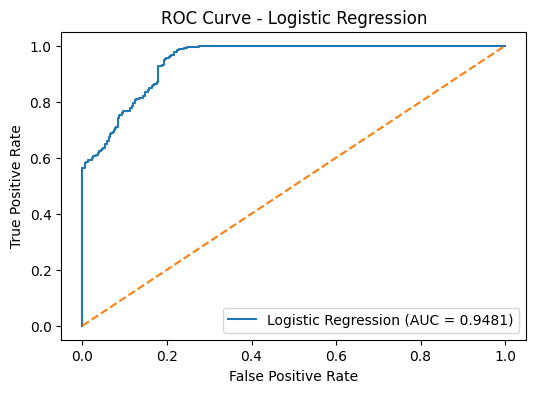

In [36]:
logistic_auc = plot_roc(
    best_lr_model, #
    X_test_scaled, #
    y_test,
    "Logistic Regression"
)

### Interpretation of the ROC Curve for Logistic Regression

The curve is well above the diagonal reference line, This means that the model is performing much better than a random classification model.

The model has an **AUC value of around 0.948** suggests that the model is performing very well in distinguishing between the two classes. In practical terms, if we randomly select an approved loan application and a rejected loan application, the model will assign a higher probability of approval to the approved application almost 94.8% of the time.

The steep increase of the curve on the left side of the plot means that the model is able to achieve a higher true positive rate while keeping the false positive rate low. This means that the model is able to successfully identify a large number of approved loans without increasing the number of false approvals.

As the curve moves to the upper right area of the plot, the true positive rate continues to rise but at the cost of a higher false positive rate. This is because there is a need to balance the true positives in approving the loan with the false positives in the approval of the loan. In the case of predicting the loan approval, it would therefore enable the decision-maker to control how conservative or permissive the approval process should be.

Overall, the ROC curve demonstrates the significance of the Logistic Regression model in recognizing the patterns of the financial attributes of the applicants and has a high level of discrimination in the approved or rejected loan applications.

### 4. Cross-Validation

In [37]:
logistic_cv_scores = evaluate_cross_validation(
    best_lr_model, #
    X_train_scaled,  #
    y_train,
    "Logistic Regression",
    cv=5
)

===== Logistic Regression Cross-Validation (5-Fold) =====
Cross-validation scores: [0.87115666 0.8477306  0.8477306  0.85505124 0.85651537]
Mean CV accuracy: 0.8556368960468521
Standard deviation: 0.008567343389943072


### Interpretation of Logistic Regression Cross-Validation Results

The results obtained from the cross-validation process show that the Logistic Regression model has an accuracy between **0.848 and 0.871**. These results indicate that the model performs consistently across different subsets of the dataset.

The fact that the model has an **average accuracy of around 0.856** implies that the model is able to perform consistently when trained on different portions of the dataset. The results are also similar to those obtained earlier, where the model achieved an accuracy of around 86%. This suggests that the model is able to perform well without relying on a single train-test split.

The results also show that **the standard deviation is around 0.0086**, which is relatively small, and this implies that the performance of the model does not vary significantly across the different folds. This suggests that the Logistic Regression model is relatively stable and that its predictions are not highly affected by variations in the training data.

###5. Coefficients

For the Logistic Regression model, coefficient analysis was used to understand how each feature influences the model’s predictions. Since Logistic Regression is a linear model, it assigns a coefficient (weight) to each feature that directly reflects its contribution to the prediction. By extracting these coefficients, it becomes possible to interpret both the direction and strength of the relationship between each feature and the target variable. Positive coefficients indicate that an increase in the feature value increases the likelihood of the positive class, while negative coefficients indicate the opposite. This method provides a clear and interpretable view of feature importance, making it particularly suitable for understanding the model’s behavior

In [38]:
import pandas as pd

# Logistic Regression coefficients
lr_coeffs = best_lr_model.coef_[0]
lr_table = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_coeffs})
print("Logistic Regression Coefficients:")
print(lr_table)

Logistic Regression Coefficients:
                     Feature  Coefficient
0           no_of_dependents    -0.046358
1                  education     0.036473
2              self_employed     0.011673
3               income_annum    -0.069793
4                loan_amount     0.040361
5                  loan_term    -0.326841
6   residential_assets_value     0.002034
7    commercial_assets_value     0.027096
8        luxury_assets_value    -0.017967
9           bank_asset_value     0.035026
10      loan_to_income_ratio     0.282654
11              total_assets     0.004210
12       asset_to_loan_ratio     0.032750
13            cibil_category     1.863456


From the results, it can be observed that cibil_category has the **largest positive coefficient** value (≈ 1.863), indicating that it has a strong influence on the model. This implies that creditworthiness is a key factor in the prediction, where individuals in higher credit categories are more likely to obtain a positive outcome (loan approval). This is consistent with real-world expectations, where financial institutions rely on credit scores for risk assessment.

It can also be observed that loan_to_income_ratio (≈ 0.283) has a relatively higher positive coefficient value compared to other features, suggesting that this factor also contributes positively to the model. In this context, a higher loan-to-income ratio may reflect a relationship captured by the data, although it may also indicate higher financial risk in practice.

On the other hand, loan_term has the **highest negative coefficient** value (≈ -0.327), indicating that longer loan durations reduce the probability of a positive outcome. This may be because longer-term loans are associated with higher risk and uncertainty, making lenders more cautious.

In addition, income_annum (≈ -0.070) and no_of_dependents (≈ -0.046) show a negative relationship with the target variable, although their impact is relatively small.

Finally, most of the remaining features, such as education, self_employed, bank_asset_value, total_assets, and commercial_assets_value, have relatively low coefficient values, indicating that they have a smaller influence on the model’s predictions.

Overall, the model places greater emphasis on financial credibility and risk-related factors, particularly credit category and loan characteristics, while other features play a secondary role in influencing the prediction.

## Evaluation of SVM

### 1. Evaluation Metrics

In [39]:
svm_metrics = evaluate_metrics(
    best_svm_model,
    X_test,
    y_test,
    "Support Vector Machine"
)


===== Support Vector Machine Metrics =====
Accuracy: 0.8981264637002342
Precision: 0.8908450704225352
Recall: 0.9529190207156308
F1 Score: 0.9208371246587808
ROC-AUC: 0.9531813914980206


Interpretation of SVM Evaluation Metrics

The tuned Support Vector Machine model was evaluated on the test set. The results demonstrate strong and consistent performance
across all evaluation metrics.

**Accuracy: 89.81%**
The model correctly classified 89.81% of all loan applications in the test set, which means it is able to correctly classify more than nine out of every ten loan applications. This indicates that the SVM model generalizes well to unseen data and makes reliable predictions for the majority of cases.

**Precision: 89.08%**
Out of all applications that the model predicted as approved, 0.8908 were actually
approved. This high precision value means that the model produces very few false
positives, which is important in a loan approval context because it reduces the
risk of approving applications that should have been rejected.

**Recall: 95.29%**
The model correctly identified  0.9529  of all loan applications that should be approved.
This means that very few approved applications were incorrectly classified as
rejected, which helps avoid unnecessary rejection of eligible applicants.

**F1-Score: 92.08%**
The F1-score combines precision and recall into a single balanced measure.
A score of 0.9208 confirms that the model maintains a strong balance between
minimizing false positives and false negatives,  reflecting its ability to correctly identify eligible applicants while avoiding unnecessary incorrect approvals.

**ROC-AUC: 0.9531**
The ROC-AUC score of 0.9531 indicates that the model has an excellent ability to
distinguish between approved and rejected loan applications across all possible
classification thresholds. A value this close to 1.0 suggests that the SVM model
is highly effective at separating the two classes.

**Overall**, the tuned SVM model demonstrates excellent classification performance
on the loan approval dataset. The combination of high precision and high recall
indicates that the model is both reliable in its approvals and thorough in
identifying eligible applicants.



###2. Confusion Matrix

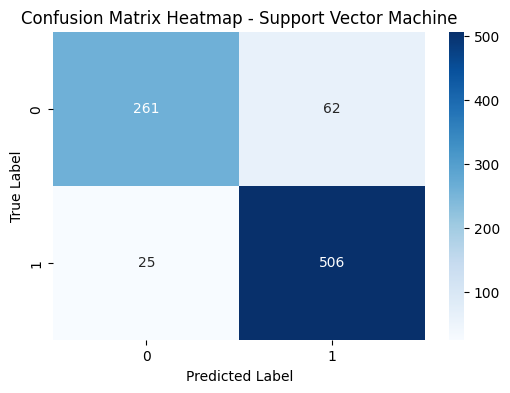

In [40]:
svm_cm = plot_confusion_matrix(
    best_svm_model,
    X_test,
    y_test,
    "Support Vector Machine"
)


 Interpretation of SVM Confusion Matrix

The confusion matrix above summarizes the classification results of the tuned SVM
model on the test set, which contains 854 samples in total.

**True Negatives (261):**
The model correctly predicted 261 loan applications as rejected. These applicants were not qualified, and the model made the right decision.

**True Positives (506):**
The model correctly predicted 506 loan applications as approved. These applicants were qualified and correctly recognized by the model.

**False Positives (62):**
The model predicted 62 applications as approved when they should have been rejected. In the context of loans, this introduces financial risk, as it may result in granting loans to unqualified applicants. Although these errors are fewer than the correct rejections (261), they still represent a notable proportion and should be carefully considered.

**False Negatives (25):**
The model predicted 25 applications as rejected when they should have been approved. This means 25 qualified applicants were turned down unnecessarily. Although this is less risky financially than false positives, it still represents missed opportunities.

**Overall**, the model performs very well, with correct predictions (261 and 506) significantly exceeding errors (62 and 25). However, the higher number of false positives compared to false negatives suggests that the model prioritizes identifying eligible applicants, even at the cost of allowing some risky approvals.

###3. ROC Curve

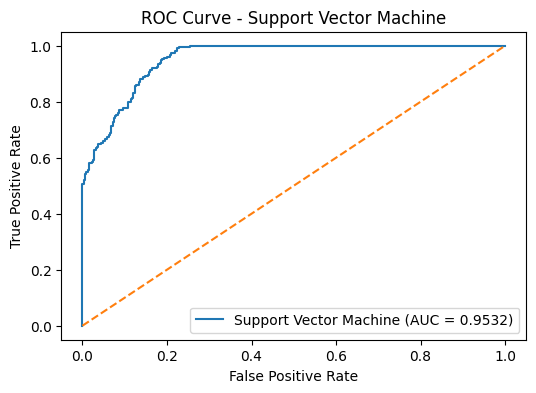

np.float64(0.9531813914980206)

In [41]:
plot_roc(
    best_svm_model,
    X_test,
    y_test,
    "Support Vector Machine"
)


 Interpretation of the ROC Curve for SVM

The ROC curve shows how well the tuned SVM model performs across different classification thresholds. It plots the True Positive Rate on the vertical axis against the False Positive Rate on the horizontal axis.

**Shape of the Curve:**
The curve rises steeply toward the upper-left corner, indicating that the model achieves a high true positive rate while maintaining a relatively low false positive rate, reflecting strong classification performance.

**AUC = 0.9532:**
The area under the curve is 0.9532, very close to 1.0. This means that if the model is given one approved and one rejected application at random, it will correctly rank the approved one higher 95.32% of the time. The high AUC shows that the model separates the two classes very well across all thresholds.

**Comparison to the Random Classifier:**
A random classifier would have an AUC of 0.5, shown by the diagonal line. The SVM curve is far above this line, confirming that the model has learned useful patterns from the data rather than guessing.

**Overall**, The ROC curve shows that the tuned SVM model is excellent at distinguishing between approved and rejected loan applications. The AUC of 0.9532 supports its selection as a reliable classifier.

###4. Cross-Validation

In [42]:
svm_cv = evaluate_cross_validation(
    best_svm_model,
    X_train,
    y_train,
    "Support Vector Machine",
    cv=5
)

===== Support Vector Machine Cross-Validation (5-Fold) =====
Cross-validation scores: [0.88872621 0.87847731 0.87847731 0.89311859 0.87701318]
Mean CV accuracy: 0.8831625183016104
Standard deviation: 0.0065083779709788625


 Interpretation of SVM Cross-Validation Results

The 5-fold cross-validation results show that the SVM model achieved accuracy
scores ranging from 0.8770 to 0.8931 across the five folds. These results
indicate that the model performs consistently across different subsets of
the dataset.

The mean cross-validation accuracy of 0.8832 is closely aligned with the
test set accuracy of 0.8981 reported earlier, which suggests that the model
generalizes well and does not rely on a single train-test split to achieve
strong performance.

The standard deviation of 0.0065  is very small, indicating that the model's
performance does not vary significantly across the different folds. This
confirms that the SVM model is stable and that its predictions are not
heavily affected by variations in the training data.

### 5. Permutation Feature Importance

For the SVM model with an RBF (non-linear) kernel, we cannot directly interpret the influence of each feature on the model’s predictions, unlike linear models where coefficients provide clear direction and magnitude. To overcome this limitation, we used permutation feature importance, which measures the change in model accuracy when the values of a feature are randomly shuffled. Features that cause a larger drop in accuracy are considered more important. This method provides a global view of which features the model relies on most, even for complex non-linear decision boundaries, while acknowledging that it does not explain individual decisions.

In [43]:
from sklearn.inspection import permutation_importance
import pandas as pd


result = permutation_importance(best_svm_model, X_test, y_test, n_repeats=10, random_state=42)

svm_importance_table = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
})

print("SVM Permutation Feature Importance:")
print(svm_importance_table)

SVM Permutation Feature Importance:
                     Feature  Importance
0           no_of_dependents    0.003162
1                  education    0.003747
2              self_employed    0.004450
3               income_annum    0.000703
4                loan_amount    0.002108
5                  loan_term    0.025878
6   residential_assets_value   -0.001522
7    commercial_assets_value    0.000585
8        luxury_assets_value    0.006323
9           bank_asset_value    0.003630
10      loan_to_income_ratio    0.008314
11              total_assets    0.002108
12       asset_to_loan_ratio    0.006440
13            cibil_category    0.338290



The permutation importance results for the RBF SVM show that cibil_category is the most important feature (0.3383), followed by loan_term (0.0259) and loan_to_income_ratio (0.0083). Other features have very low or almost zero importance, with some slightly negative due to minor variations in the permutation process. These negative values are negligible and show that these features have little effect on the model's predictions. Overall, this tells us which features the SVM relies on the most, although it does not explain individual predictions.

## Evaluation of Random Forest

### 1. Evaluation Metrics

In [44]:
rf_metrics = evaluate_metrics(
    best_rf_model,
    X_test,
    y_test,
    "Random Forest"
)

===== Random Forest Metrics =====
Accuracy: 0.9250585480093677
Precision: 0.892436974789916
Recall: 1.0
F1 Score: 0.9431616341030196
ROC-AUC: 0.952965664410278


Interpretation of Random Forest Evaluation Metrics


The tuned Random Forest model was evaluated on the test set. The results demonstrate strong and consistent performance across all evaluation metrics.

**Accuracy: 92.51%**
The model correctly classified 92.51% of all loan applications in the test set. This indicates that the Random Forest model generalizes well to unseen data and makes reliable predictions for the vast majority of cases.

**Precision: 89.24%**
Out of all applications that the model predicted as approved, 0.8924 were actually approved. This means the model produces a relatively small number of false positives, which is important in a loan approval context because it reduces the risk of approving applications that should have been rejected.

**Recall: 100%**
The model correctly identified all loan applications that should be approved, with zero false negatives. This means no eligible applicant was incorrectly classified as rejected, reflecting the model's strong sensitivity toward the approved class.

**F1-Score: 94.31%**
The F1-score of 0.9431 confirms a strong balance between precision and recall. The slight gap from 1.0 is directly tied to the imperfect precision, as the model occasionally approves applications that should be rejected.

**ROC-AUC: 0.9530**
The ROC-AUC score of 0.9530 indicates that the model has an excellent ability to distinguish between approved and rejected loan applications across all possible classification thresholds.

**Overall**, the tuned Random Forest model demonstrates excellent classification performance on the loan approval dataset. The perfect recall combined with high precision and F1-score confirms that the model is both thorough in identifying eligible applicants and reliable in its approval decisions.


###2. Confusion Matrix

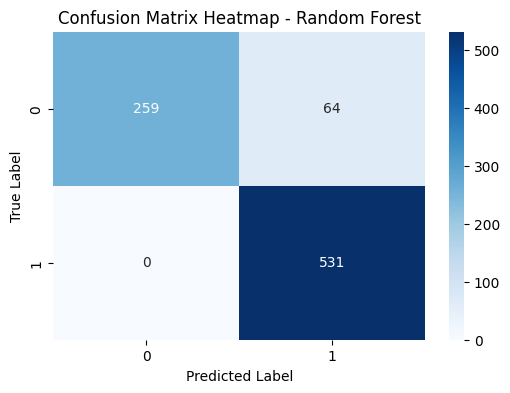

In [45]:
rf_cm = plot_confusion_matrix(
    best_rf_model,
    X_test,
    y_test,
    "Random Forest"
)

Interpretation of Random Forest Confusion Matrix


The confusion matrix above summarizes the classification results of the Random Forest model on the test dataset.

**True Negatives (259):** The model correctly classified 259 rejected loan applications, successfully identifying them as rejected without any errors.

**False Positives (64):** The model incorrectly classified 64 rejected applications as approved. This means the model predicted approval for cases that should have been rejected, which directly explains why the precision (89.24%) is below 1.0.

**False Negatives (0):** No approved applications were incorrectly classified as rejected. This is what drives the perfect Recall of 1.0, as the model did not miss a single truly approved application.

**True Positives (531):** The model correctly classified all 531 approved loan applications, confirming its strong ability to detect positive cases.

**Overall**, the confusion matrix reveals an asymmetric error pattern in the Random Forest model. While it achieves perfect recall by capturing every approved application, it struggles slightly with rejected cases, misclassifying 64 of them as approved. This trade-off suggests the model is tuned toward minimizing missed approvals, which may be acceptable depending on the business context, but the 64 false positives should be taken into consideration when deploying the model in a real loan advisory system.


###3. ROC Curve

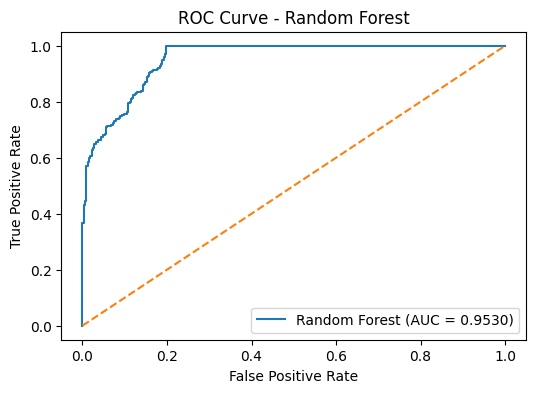

In [46]:
rf_auc = plot_roc(
    best_rf_model,
    X_test,
    y_test,
    "Random Forest"
)

Interpretation of the ROC Curve for Random Forest

The ROC curve above illustrates the performance of the Random Forest model across all classification thresholds.

**Curve Shape:** The curve rises sharply toward the upper-left corner at a very low False Positive Rate, indicating that the model achieves a high True Positive Rate early on. This shape reflects the model's strong ability to correctly identify approved loan applications while keeping false approvals low across most thresholds.

**AUC = 0.9530:** The area under the ROC curve is 0.9530, which indicates excellent discriminative ability between approved and rejected loan applications. A value this close to 1.0 means the model is highly effective at ranking approved cases above rejected ones across all possible decision thresholds.

**Comparison to Random Classifier:** Compared to the diagonal reference line which represents a random classifier with no predictive power, the Random Forest curve stays well above it across all thresholds, confirming that the model performs substantially better than random chance.

**Overall**, the ROC curve confirms that the Random Forest model achieves excellent class separation on the test set with an AUC of 0.9530. This result is consistent with the other evaluation metrics and reflects a well-tuned model that generalizes reliably to unseen data.

###4. Cross-Validation

In [47]:
rf_cv_scores = evaluate_cross_validation(ط
    best_rf_model,
    X_train,
    y_train,
    "Random Forest",
    cv=5
)

===== Random Forest Cross-Validation (5-Fold) =====
Cross-validation scores: [0.9238653  0.90190337 0.91947291 0.92532943 0.91654466]
Mean CV accuracy: 0.9174231332357248
Standard deviation: 0.008364777075892062


Interpretation of Random Forest Cross-Validation Results

The 5-fold cross-validation results show that the Random Forest model performs consistently across different subsets of the training data.

**Cross-Validation Scores:** The individual fold scores are [0.9239, 0.9019, 0.9195, 0.9253, 0.9165], all falling within a narrow range close to 0.92. This tight grouping indicates that the model does not depend heavily on any particular subset of the data and generalizes reliably across different training and validation splits.

**Mean CV Accuracy: 0.9174:** The mean cross-validation accuracy of 0.9174 reflects strong and consistent predictive performance across all five folds, confirming that the model captures the underlying patterns in the loan approval data effectively.

**Standard Deviation: 0.0084:** The very low standard deviation of 0.0084 indicates that the model's performance is stable and does not vary substantially across folds. This low variance is a strong sign that the model is neither overfitting to specific training subsets nor sensitive to how the data is split.

**Overall**, the cross-validation results support the reliability and robustness of the Random Forest model. The combination of high mean accuracy and low variance confirms that the model generalizes well to unseen data, and the results are consistent with the test set evaluation metrics observed earlier.


###5.Feature Importance

In addition to evaluating model performance using standard metrics, it is important to understand
how the model makes its predictions. Feature importance analysis provides insight into the
contribution of each input variable to the model's decision-making process.

For tree-based models such as Random Forest, feature importance is calculated based on how much
each feature reduces impurity across all decision trees. Features with higher importance scores
have a greater influence on the model's predictions.

This analysis is particularly useful for interpreting the model and identifying which variables
play a key role in distinguishing between approved and rejected loan applications. It also helps
assess whether the model relies heavily on a small subset of features or utilizes a broader set
of information.

The following section presents the feature importance visualization for the trained Random Forest model.


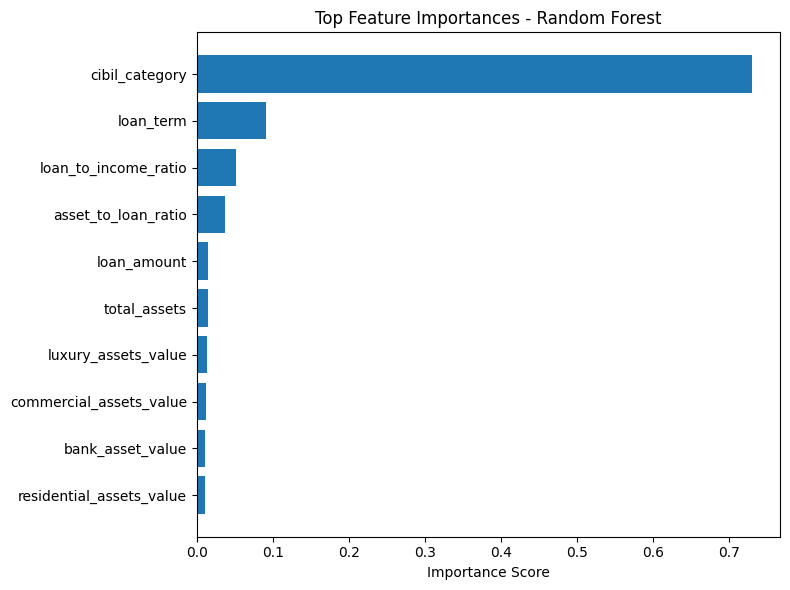

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_importance(model, feature_names, top_n=10):

    # Extract importance scores from the trained model
    importances = model.feature_importances_

    # Sort features from highest to lowest importance
    indices = importances.argsort()[::-1]

    # Select only the top_n most important features
    top_features = indices[:top_n]

    # Plot horizontal bar chart
    plt.figure(figsize=(8, 6))
    plt.title("Top Feature Importances - Random Forest")
    plt.barh(range(top_n), importances[top_features][::-1])
    plt.yticks(range(top_n), [feature_names[i] for i in top_features][::-1])
    plt.xlabel("Importance Score")
    plt.tight_layout()

    # Save the figure to the project plots folder
    plt.savefig("Supervised_Learning/plots/Random Forest_Feature_Importances.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# Run the function using the best tuned Random Forest model
plot_feature_importance(best_rf_model, X_train.columns)

Interpretation of Random Forest Feature Importance

 feature importance plot reveals that the model relies heavily on a single feature,
**cibil_category**, which has a significantly higher importance score (0.75) compared to all
other variables. This indicates that cibil_category is by far the most dominant factor in the
model's loan approval decisions, which makes practical sense since credit scores are typically
the primary criterion used by financial institutions to assess loan eligibility.

Other features such as **loan_term** (0.10), loan_to_income_ratio (0.05), and
**asset_to_loan_ratio** (0.04) contribute modestly to the predictions, while the remaining
features including loan_amount, total_assets, luxury_assets_value, commercial_assets_value,
bank_asset_value, and residential_assets_value have minimal influence on the model's output.

This strong imbalance in feature importance directly explains the high performance observed
across all evaluation metrics. When a single feature is this predictive, the model can acThehieve
very high accuracy (92.51%), perfect recall (100%), and strong F1-score (94.31%) by primarily
relying on cibil_category to separate approved from rejected applications.

While this behavior leads to excellent predictive results, it also raises important
considerations. A model that depends heavily on one feature may not fully capture the broader
relationships within the dataset. Additionally, if cibil_category were unavailable or unreliable
in a real deployment scenario, the model's performance could drop significantly.

**Overall**, the feature importance analysis provides a clear explanation for the strong
performance observed in previous evaluation results, and highlights the need to carefully
consider feature dependency when deploying the model in a real loan advisory system.

# **5. Comparative Analysis & Interpretation**


In this section, the three trained models (logistic Regression, SVM, and Random Forest) are compared based on their performance metrics, error analysis ,
cross-validation stability, and trade-offs. The goal is to identify which model
performs best for the loan approval prediction task and understand the strengths
and limitations of each approach.

## 5.1 Performance Metrics Comparison & Error analysis

In [ ]:
#  COMPARISON TABLE

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

# Collect all metrics for each model into a single DataFrame

def get_all_metrics(model, X_test_input, y_test, model_name):
    """Compute all classification metrics and return as a dict."""
    y_pred  = model.predict(X_test_input)
    y_score = model.predict_proba(X_test_input)[:, 1]
    cm      = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Model"     : model_name,
        "Accuracy"  : round(accuracy_score(y_test, y_pred),   4),
        "Precision" : round(precision_score(y_test, y_pred),  4),
        "Recall"    : round(recall_score(y_test, y_pred),     4),
        "F1 Score"  : round(f1_score(y_test, y_pred),         4),
        "ROC-AUC"   : round(roc_auc_score(y_test, y_score),   4),
        "FP" : int(fp),
        "FN": int(fn),
    }

# Collect results
results = [
    get_all_metrics(best_lr_model,  X_test_scaled, y_test, "Logistic Regression"),
    get_all_metrics(best_svm_model, X_test,        y_test, "SVM"),
    get_all_metrics(best_rf_model,  X_test,        y_test, "Random Forest"),
]


# Build DataFrame and style it for clear display
df_results = pd.DataFrame(results).set_index("Model")
df_results.to_csv("Supervised_Learning/evaluation_results/model_comparison.csv", index=True)

# Highlight the best value in each metric column
styled = (
    df_results
    .style
    .highlight_max(
        subset=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"],
        color="#c8e6c9"        # green = best
    )
    .highlight_min(
        subset=["FP","FN"],
        color="#c8e6c9"        # green = fewest errors
    )
    .format("{:.4f}", subset=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"])
    .set_caption(" Model Performance Comparison ")
)

display(styled)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,FP,FN
Model,,,,,,,
Logistic Regression,0.8677,0.8914,0.8964,0.8939,0.9481,58,55
SVM,0.8981,0.8908,0.9529,0.9208,0.9532,62,25
Random Forest,0.9251,0.8924,1.0000,0.9432,0.9530,64,0


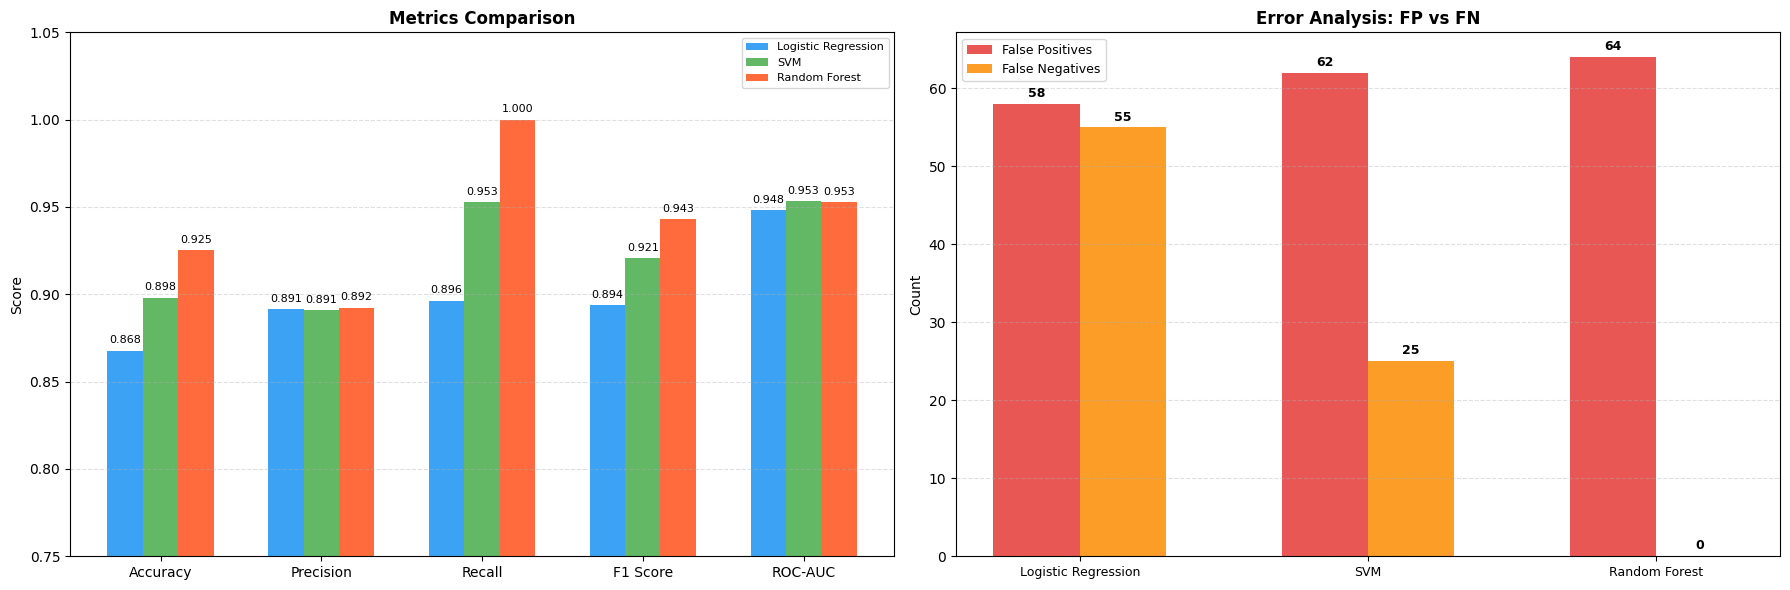

In [ ]:
#  VISUALIZATIONS

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = ["#2196F3", "#4CAF50", "#FF5722"]
model_names = df_results.index.tolist()

# Bar Chart: Accuracy / F1 / ROC-AUC / Precision / Recall
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
x = np.arange(len(metrics_to_plot))
bar_width = 0.22
ax1 = axes[0]

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [df_results.loc[name, m] for m in metrics_to_plot]
    bars = ax1.bar(x + i * bar_width, vals, bar_width,
                   label=name, color=color, alpha=0.88)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.003,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax1.set_xticks(x + bar_width)
ax1.set_xticklabels(metrics_to_plot, fontsize=10)
ax1.set_ylim(0.75, 1.05)
ax1.set_ylabel("Score")
ax1.set_title("Metrics Comparison", fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Error Analysis: FP vs FN
ax2 = axes[1]
x2 = np.arange(len(model_names))
bw = 0.3

bars_fp = ax2.bar(x2 - bw/2, df_results["FP"], bw,
                  label="False Positives", color="#E53935", alpha=0.85)
bars_fn = ax2.bar(x2 + bw/2, df_results["FN"], bw,
                  label="False Negatives", color="#FB8C00", alpha=0.85)

for bar in list(bars_fp) + list(bars_fn):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             str(int(bar.get_height())),
             ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_xticks(x2)
ax2.set_xticklabels(model_names, fontsize=9)
ax2.set_ylabel("Count")
ax2.set_title("Error Analysis: FP vs FN", fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("Supervised_Learning/plots/MetricsComparison_ErrorAnalysis.png", dpi=150, bbox_inches="tight")
plt.show()

 Results Interpretation

The comparison table and bar charts reveal clear performance differences across
the three models.

**Logistic Regression** achieved 86.8% accuracy with a precision of 0.8914, meaning it produces relatively few false approvals. However, it recorded the highest False Negatives (55), indicating it incorrectly rejected the most eligible applicants among the three models. This is expected given its linear decision boundary, which cannot fully capture the complex relationships between financial features.

**SVM** achieved 89.81% accuracy with a Recall of 0.9529 and ROC-AUC of 0.9532, confirming that a nonlinear boundary better fits this dataset. It recorded 62 FP and 25 FN, reflecting a higher recall at the cost of slightly more false approvals (62 FP vs. 58 FP) compared to Logistic Regression.

**Random Forest** achieved the highest accuracy (92.51%) with a perfect Recall of 1.0, meaning it correctly identified every eligible applicant with zero False Negatives. However, it recorded the highest False Positives (64), indicating it approved some ineligible applicants. Its ROC-AUC of 0.9530 is comparable to SVM, suggesting similar discriminative ability overall.

Overall, Random Forest achieved the highest accuracy (92.51%) and perfect recall (1.0000), meaning it successfully identified every eligible applicant with no missed approvals. Although it recorded slightly more false positives than the other models, this trade-off is acceptable when the business prioritizes maximizing approved eligible applicants over minimizing financial risk in a loan approval context where missing a qualified applicant carries a higher cost. Therefore, Random Forest is considered the best-performing model in this comparison.

## 5.2 Cross-Validation Analysis

In [49]:
# ── CROSS-VALIDATION COMPARISON TABLE

cv_data = {
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "CV Mean Accuracy": [
        round(logistic_cv_scores.mean(), 4),
        round(svm_cv.mean(), 4),
        round(rf_cv_scores.mean(), 4),
    ],
    "CV Std": [
        round(logistic_cv_scores.std(), 4),
        round(svm_cv.std(), 4),
        round(rf_cv_scores.std(), 4),
    ],
}

df_cv = pd.DataFrame(cv_data).set_index("Model")
df_cv.to_csv("Supervised_Learning/evaluation_results/cv_comparison.csv")

styled_cv = (
    df_cv
    .style
    .format("{:.4f}")
    .set_caption("Cross-Validation Results (5-Fold)")
)

display(styled_cv)

,CV Mean Accuracy,CV Std
Model,,
Logistic Regression,0.8556,0.0086
SVM,0.8832,0.0065
Random Forest,0.9174,0.0084


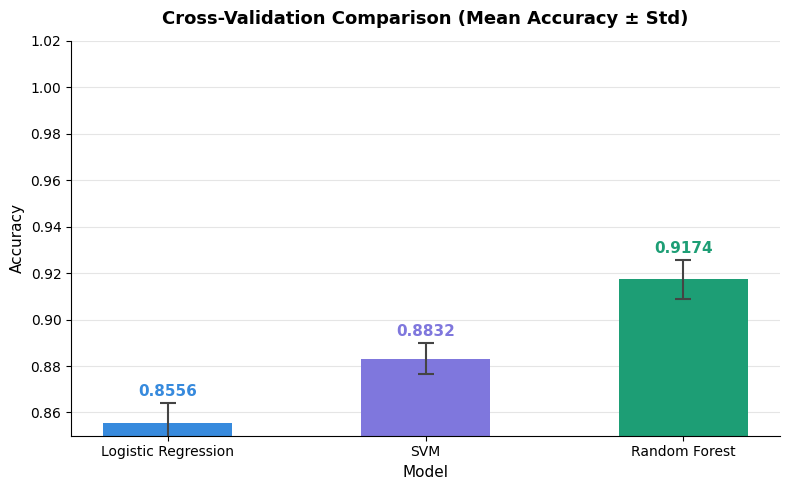

In [50]:
import matplotlib.pyplot as plt
import numpy as np

models = df_cv.index.tolist()
means  = df_cv["CV Mean Accuracy"].values
stds   = df_cv["CV Std"].values

colors = ["#378ADD", "#7F77DD", "#1D9E75"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(models, means, yerr=stds, capsize=6,
              color=colors, width=0.5,
              error_kw=dict(elinewidth=1.5, ecolor="#444", capthick=1.5))

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.003,
            f"{mean:.4f}",
            ha="center", fontsize=11, fontweight="bold",
            color=bar.get_facecolor())

ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_xlabel("Model", fontsize=11)
ax.set_title("Cross-Validation Comparison (Mean Accuracy ± Std)", fontsize=13, fontweight="bold", pad=12)

ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color="#E5E5E5", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("Supervised_Learning/plots/cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Cross-Validation Interpretation

The 5-fold cross-validation results confirm the consistency of all three models
across different data splits.

**Logistic Regression**
achieved a mean CV accuracy of 0.8556 with a std of 0.0086, indicating stable but moderate performance, consistent with its test accuracy of 0.8677.

**SVM** achieved a mean CV accuracy of 0.8832 with the lowest std of 0.0065, making it the most stable model. This indicates that SVM generalizes reliably across different subsets of the data.

**Random Forest**  achieved the highest mean CV accuracy of 0.9174 with a std of 0.0084, and its test accuracy of 0.9251 is closely aligned with its CV mean, confirming that the model generalizes well.

Overall, all three models show low standard deviation, confirming stable and consistent performance across splits. Random Forest leads in accuracy, while SVM demonstrates the tightest variance, reflecting strong reliability across folds.

##5.3 Overfitting

In this part, we discuss the overfitting behavior of the three models. Overfitting occurs when a model performs well on the training data but fails to generalize to new, unseen data, resulting in a significant drop in performance on the test set.

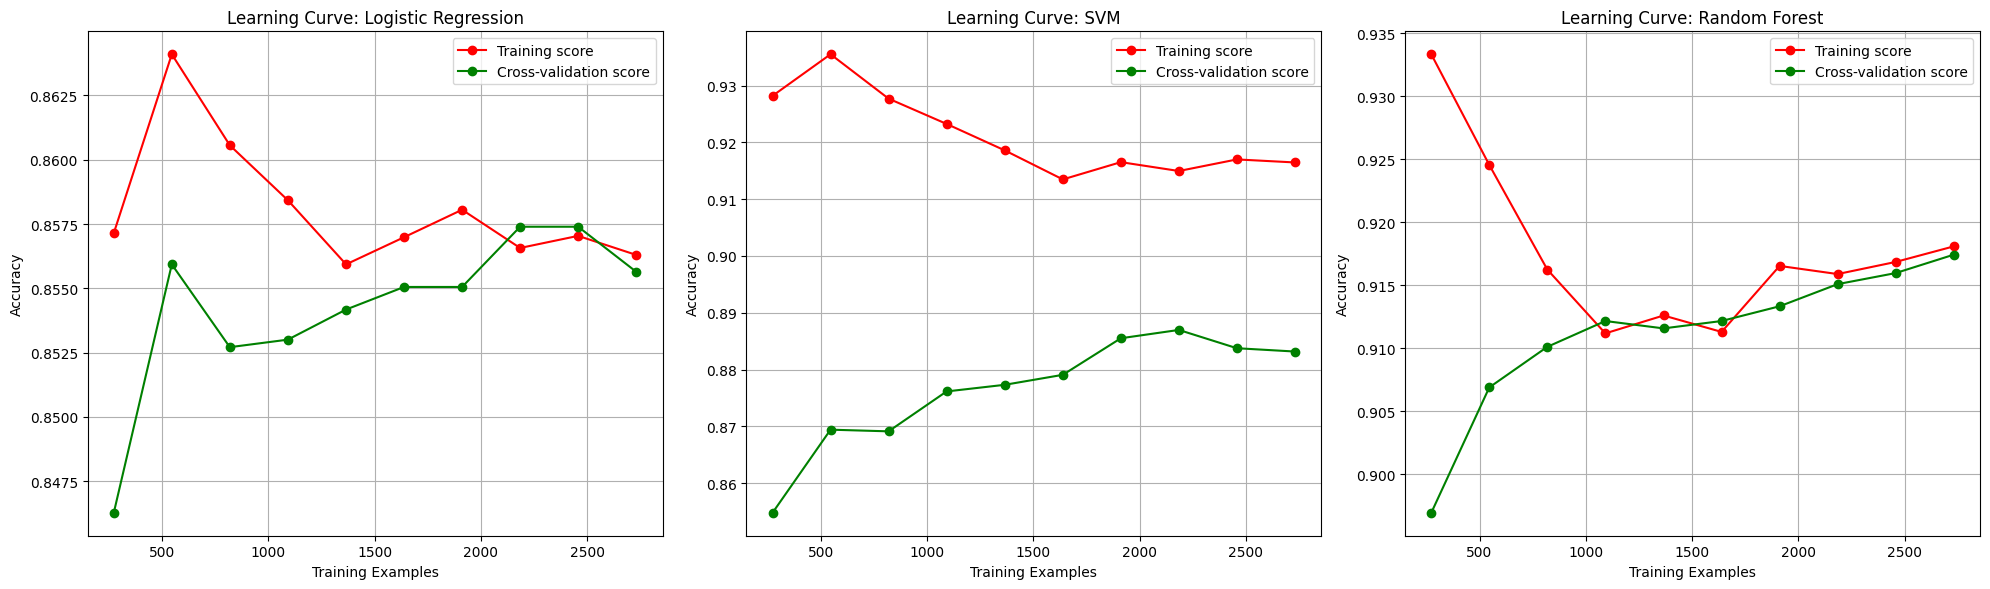

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
# Function to plot learning curves for multiple models side by side
def plot_all_learning_curves(models, X, y):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    # Loop over each model and its corresponding subplot
    for ax, (name, model, train_x) in zip(axes, models):
       # Compute learning curve: training and cross-validation scores
        train_sizes, train_scores, test_scores = learning_curve(
            model, train_x, y, cv=5, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
        )

        train_mean = np.mean(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
         # Plot training and CV scores
        ax.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
        ax.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
        ax.set_title(f"Learning Curve: {name}")
        ax.set_xlabel("Training Examples")
        ax.set_ylabel("Accuracy")
        ax.legend(loc="best")
        ax.grid(True)

        plt.tight_layout()
        plt.savefig("learning_curves_comparison.png", dpi=300, bbox_inches='tight')

models_to_plot = [
    ("Logistic Regression", best_lr_model, X_train_scaled),
    ("SVM", best_svm_model, X_train),
    ("Random Forest", best_rf_model, X_train)
]

plot_all_learning_curves(models_to_plot, X_train, y_train)

Overfitting Analysis

Logistic Regression shows a small gap between the training and cross-validation scores throughout the learning curve, and the two curves converge as more data is added. This indicates minimal overfitting and stable behavior, which is expected from a simple linear model.

SVM shows a larger gap, with the training score consistently higher than the cross-validation score. However, the CV score improves steadily as more training data are added, suggesting moderate overfitting that could be reduced with more data.

Random Forest starts with a large gap at small training sizes, but the two curves converge clearly as training size increases. This indicates  that the model's generalization improves with more data and that overfitting decreases as the training set grows.

Overall, all three models get better with more training data. Logistic Regression stays stable, SVM has some overfitting that lessens with more data, and Random Forest improves the most while overfitting less. This shows that more data helps all models, especially the complex ones, make better predictions.




## 5.4 Misclassification Analysis  

The error analysis reveals clear patterns of misclassification across the three models.

Logistic Regression produced the highest number of false negatives (FN = 55), indicating that it struggled to correctly identify eligible applicants. This pattern aligns with the limitations of a linear decision boundary, which cannot fully capture complex relationships between financial features.

SVM recorded 62 false positives (FP) and 25 false negatives (FN), showing a different trade-off: it tends to approve more applicants, missing fewer eligible ones but occasionally approving ineligible ones. This behavior reflects the flexibility of the nonlinear RBF boundary in fitting the data.

Random Forest produced zero false negatives (FN = 0) with 64 false positives, successfully identifying every eligible applicant at the cost of approving some ineligible ones. In a loan approval context, minimizing missed approvals is often prioritized, making this trade-off reasonable.

Across all models, the most challenging cases involve applicants with conflicting financial signals, such as high income combined with a low CIBIL score, or strong credit history with low asset value. These borderline cases are difficult to classify correctly and account for most of the observed errors.

Additionally, the mild class imbalance in the dataset (2,656 approved vs. 1,613 rejected) may have influenced the models toward the majority class, contributing to the higher false negatives in Logistic Regression. Feature scaling was applied to mitigate sensitivity to magnitude differences, although natural variance in financial features may still affect borderline classifications, particularly for Logistic Regression and SVM.

## 5.5 Trade-off Analysis

**Accuracy vs Interpretability:**

Random Forest and SVM achieved the highest accuracy among the three models, indicating they are very effective at correctly predicting loan approvals. However, they offer limited interpretability. Random Forest provides feature importance scores, showing which features influence the model’s predictions globally, for example, cibil_category is the most important, followed by loan_term and loan_to_income_ratio. SVM with an RBF kernel cannot provide direct coefficients, so we used permutation feature importance to estimate which features the model relies on, showing a similar ranking. Even with this, both models cannot explain individual decisions, meaning it is difficult to justify why a specific applicant was rejected or approved.

In contrast, Logistic Regression, while slightly less accurate, offers full transparency through its coefficients. Each feature’s coefficient indicates both the direction and magnitude of influence on the final prediction. For instance, a cibil_category coefficient of 1.8634 strongly increases the likelihood of approval, while loan_term = -0.326 reduces it. This allows stakeholders or regulators to understand precisely why a particular decision was made. Therefore, Logistic Regression strikes a balance between performance and interpretability, making it the most suitable choice in regulated financial environments where explainability is critical, even if it sacrifices a small amount of accuracy compared to Random Forest or SVM.



**Accuracy vs Computational Cost:**

| Model | GridSearchCV Fits |
|---|---|
| Logistic Regression | 50 fits (10 combinations × 5 folds) |
| SVM | 120 fits (24 combinations × 5 folds) |
| Random Forest | 135 fits (27 combinations × 5 folds) |

The computational cost varies across the models based on both the number of fits and the inherent complexity of each algorithm. Each fit represents a full training cycle during cross validation, where the model processes the entire dataset to learn patterns. As the number of fits increases, the CPU performs more repeated computations, leading to longer processing time and higher resource usage. Logistic Regression required only 50 fits, making it the least computationally expensive model, while still achieving a strong accuracy of 86.77%. In contrast, SVM required 120 fits and achieved 89.81% accuracy, while Random Forest required 135 fits and achieved perfect accuracy on the test set, which may indicate a highly separable dataset.

In addition to the number of fits, Random Forest is inherently more computationally expensive due to its ensemble structure, where multiple decision trees are trained and combined. This further increases both processing time and memory usage. Therefore, a clear trade-off exists: higher accuracy comes at the cost of increased computational expense. Random Forest is the most costly model, followed by SVM, while Logistic Regression remains the most efficient relative to its performance.

# **6. Conclusion: Best Model Selection & Reasoning**


The results show that Random Forest achieved the highest overall accuracy of approximately **92.51%**, which is higher than both Support Vector Machine and Logistic Regression. In addition, it achieved a **perfect recall of 1.0000**, meaning that it was able to correctly identify all eligible loan applicants without producing any false negatives. This is an important advantage in the loan approval task, especially when correctly identifying qualified applicants is a priority.

The model also achieved a strong **ROC-AUC score of approximately 0.9530**, which is comparable to the SVM model and indicates excellent ability to distinguish between approved and rejected loan applications. Although Random Forest recorded slightly more false positives than the other models, its ability to maximize correct approval detection makes it the strongest overall performer in this comparison.

Furthermore, the cross-validation analysis shows that the Random Forest model is consistent and stable across different subsets of the data, which supports its reliability as a final model.

The Support Vector Machine (SVM) model was not selected despite its strong performance. Although it achieved high accuracy and a strong ROC-AUC score, its performance is slightly lower than Random Forest across the evaluation metrics. Therefore, while SVM is a reliable and well-balanced model, it does not outperform Random Forest in this task.

Similarly, Logistic Regression was not selected as the final model. Although it provides good performance and strong interpretability, its accuracy is lower compared to both Random Forest and SVM.

Therefore, Random Forest is chosen as the final model because it achieved the best overall performance and demonstrated strong consistency.

# **7. Next Steps for Phase 2 Integration**


Building on the results achieved in Phase 1, the following steps outline how the supervised
learning models will be enhanced and integrated in Phase 2.

**Part A: Unsupervised Learning**

The preprocessed dataset will serve as the input for the clustering phase. Before applying any
clustering algorithm, the target variable loan_status will be removed so that clusters are
formed purely based on the financial profiles of applicants, without any influence from known
labels.

Two clustering algorithms will be applied and compared. K-Means is a strong candidate given the
dataset's numerical structure and moderate size, as it is efficient and produces interpretable
spherical clusters. DBSCAN will also be explored, as it can detect irregular groupings and
identify outliers among applicant profiles, which is particularly relevant in financial data
where anomalous cases are common. The optimal number of clusters for K-Means will be determined
using the Elbow Method and Silhouette Score to ensure meaningful groupings.

Once clusters are formed, each cluster will be profiled and interpreted in terms of its
financial characteristics. For example, one cluster may represent high-income applicants with
strong credit scores, while another may group borderline or high-risk profiles. These cluster
profiles will provide richer context about applicant segments beyond a simple approved or
rejected prediction, and will inform how the Generative AI component personalizes its responses
in Part B.

**Part B: Generative AI Integration**

The Random Forest model selected in Phase 1 will serve as the prediction backbone for the
Generative AI component, given its strong performance across all evaluation metrics. For each
applicant, the model's prediction along with the applicant's financial features and assigned
cluster profile will be passed to a generative model via API to produce a clear, human-readable
explanation of the loan decision.

Four distinct prompt templates will be designed and tested, each targeting a different use case.
The first template will provide a basic explanation of the prediction outcome. The second will
deliver detailed financial reasoning based on the applicant's specific feature values. The third
will incorporate the cluster profile identified in Part A to produce a personalized,
context-aware response. The fourth will simplify the explanation for non-expert applicants who
may not be familiar with financial terminology. All templates will be evaluated for relevance,
clarity, completeness, and factual accuracy across multiple test cases.

Throughout this phase, API keys will be stored securely in environment variables and excluded
from the repository via .gitignore to ensure safe handling of sensitive credentials.
